# 07 — Scenario Analysis & Strategy

Three Iran conflict scenarios with probability-weighted expected returns.

| Scenario | WTI Target | Prob | Horizon |
|---|---|---|---|
| Short Conflict | $82 | 50% | 15 days |
| Prolonged Conflict | $100 | 35% | 85 days |
| Escalation | $135 | 15% | 126 days |

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join('..', '..')))

import pickle, numpy as np, pandas as pd
import matplotlib.pyplot as plt

from energy_workbook.config import (
    ALL_TICKERS, EQUITY_TICKERS, RF_RATE, FUNDAMENTALS,
    SCENARIO_NAMES, SCENARIO_PROBS, SCENARIO_INPUTS, SCENARIO_HORIZON_DAYS,
)

VIZ = os.path.abspath(os.path.join('..', 'visualization'))
DATA = os.path.abspath(os.path.join('..', 'data'))

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 11, 'axes.titlesize': 14,
    'figure.facecolor': 'white', 'axes.facecolor': '#FAFAFA',
    'axes.edgecolor': '#CCCCCC', 'axes.grid': True,
    'grid.alpha': 0.3, 'legend.fontsize': 9,
})
MC_COLORS = ['#002B5C','#1A3C6E','#4A86C8','#0070C0','#C89600',
             '#E06C00','#C00000','#008000','#7030A0','#666666']

def savefig(fig, name, dpi=180):
    fig.savefig(os.path.join(VIZ, name), dpi=dpi, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    print(f'  saved {name}')

cache_path = os.path.abspath(os.path.join('..', '..', 'data_cache.pkl'))
with open(cache_path, 'rb') as f:
    D = pickle.load(f)
MASTER = D['master']; LOG_RET = D['log_returns']; DIFFS = D['diffs']
print('Data loaded')

Data loaded


## 7.1 Multi-Factor Regression (for scenario projection)

In [2]:
# Build factor matrix
factor_names = ['R_WTI', 'dVIX', 'dSpread_2s10s', 'dDXY_log', 'dT10YIE', 'dOVX']
factors = pd.DataFrame(index=MASTER.index)
factor_map = {
    'R_WTI': ('log_returns', 'WTI'),
    'dVIX': ('diffs', 'dVIX'),
    'dSpread_2s10s': ('diffs', 'dSpread_2s10s'),
    'dDXY_log': ('diffs', 'dDXY_log'),
    'dT10YIE': ('diffs', 'dT10YIE'),
    'dOVX': ('diffs', 'dOVX'),
}
for fn, (src, col) in factor_map.items():
    s = D[src] if src in D else pd.DataFrame()
    if col in s.columns:
        factors[fn] = s[col]
factors = factors.dropna()

reg_results = {}
for t in EQUITY_TICKERS:
    y = LOG_RET.get(t, pd.Series(dtype=float))
    common = factors.index.intersection(y.dropna().index)
    if len(common) < 60: continue
    Y = y[common].values
    X = np.column_stack([np.ones(len(common)), factors.loc[common].values])
    try:
        betas = np.linalg.lstsq(X, Y, rcond=None)[0]
        resid = Y - X @ betas
        sst = np.sum((Y - Y.mean())**2)
        reg_results[t] = {
            'betas': betas,
            'r2': float(1 - np.sum(resid**2)/sst) if sst > 0 else 0,
        }
    except: pass

print(f'Regression results for {len(reg_results)} tickers')

Regression results for 9 tickers


## 7.2 Scenario Returns

In [3]:
wti = MASTER.get('WTI', pd.Series(dtype=float))
wti_current = float(wti.dropna().iloc[-1]) if len(wti.dropna()) > 0 else 75

scenario_rets = {}
for t in EQUITY_TICKERS:
    if t not in reg_results: continue
    betas = reg_results[t]['betas']
    srets = []
    for sname in SCENARIO_NAMES:
        si = SCENARIO_INPUTS[sname]
        hd = SCENARIO_HORIZON_DAYS.get(sname, 60)
        r_oil = np.log(si['wti_target'] / wti_current) if wti_current > 0 else 0
        exp = betas[0] * hd
        if len(betas) > 1: exp += betas[1] * r_oil
        if len(betas) > 2: exp += betas[2] * si['vix_delta']
        if len(betas) > 3: exp += betas[3] * si['spread_2s10s_delta']
        if len(betas) > 4: exp += betas[4] * np.log(1 + si.get('dxy_pct', 0))
        if len(betas) > 5: exp += betas[5] * si.get('breakeven_delta', 0)
        if len(betas) > 6: exp += betas[6] * si.get('ovx_delta', 0)
        srets.append(float(exp))
    scenario_rets[t] = {
        'scenarios': srets,
        'weighted': sum(r * p for r, p in zip(srets, SCENARIO_PROBS))
    }

# Export
sc_export = pd.DataFrame({
    t: {'short': s['scenarios'][0], 'prolonged': s['scenarios'][1],
         'escalation': s['scenarios'][2], 'weighted': s['weighted']}
    for t, s in scenario_rets.items()
}).T
sc_export.to_csv(os.path.join(DATA, 'scenario_returns.csv'))
(sc_export * 100).round(2)

,short,prolonged,escalation,weighted
XOM,-4.31,10.23,37.92,7.12
CVX,-2.85,12.20,43.78,9.41
COP,-5.77,12.14,48.60,8.65
OXY,-8.39,11.48,60.83,8.95
LNG,-1.60,13.85,41.43,10.26
VG,-18.44,-0.96,50.47,-1.99
FRO,0.14,16.47,41.67,12.08
STNG,-1.69,5.88,15.66,3.56
ET,-5.64,4.74,24.72,2.55


  saved 07_scenario_returns.png


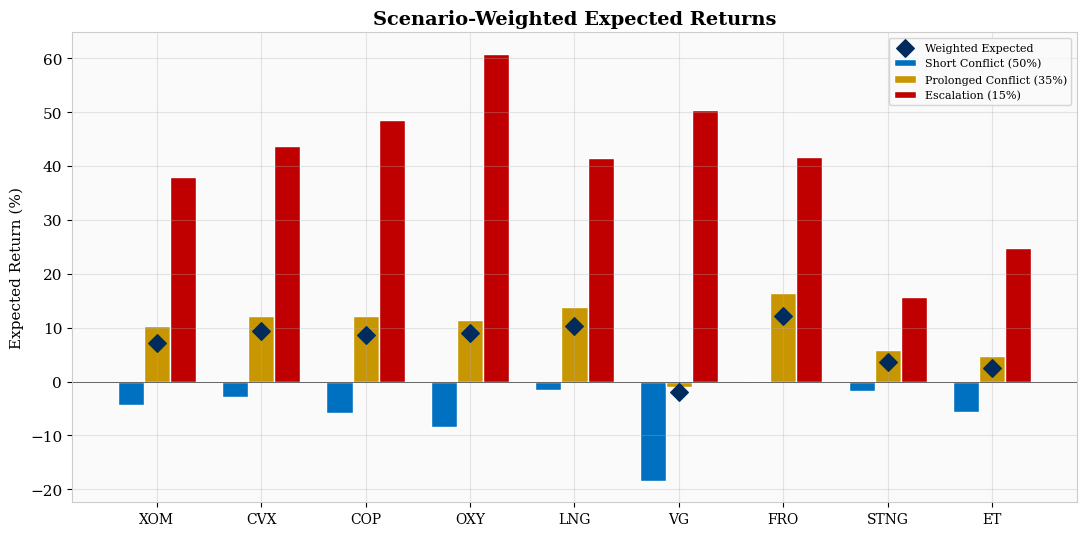

In [4]:
# Scenario Returns Bar Chart
fig, ax = plt.subplots(figsize=(11, 5.5))
sc_t = [t for t in EQUITY_TICKERS if t in scenario_rets]
x = np.arange(len(sc_t)); w = 0.25
sc_cl = ['#0070C0', '#C89600', '#C00000']

for i, (sn, cl) in enumerate(zip(SCENARIO_NAMES, sc_cl)):
    vals = [scenario_rets[t]['scenarios'][i] * 100 for t in sc_t]
    ax.bar(x + i*w - w, vals, w, label=f'{sn} ({int(SCENARIO_PROBS[i]*100)}%)',
           color=cl, edgecolor='white')

wv = [scenario_rets[t]['weighted'] * 100 for t in sc_t]
ax.scatter(x, wv, color='#002B5C', s=80, zorder=5, marker='D', label='Weighted Expected')
ax.set_xticks(x); ax.set_xticklabels(sc_t, fontsize=10)
ax.set_ylabel('Expected Return (%)')
ax.set_title('Scenario-Weighted Expected Returns', fontweight='bold')
ax.axhline(0, color='#333', linewidth=0.5)
ax.legend(fontsize=8)
fig.tight_layout()
savefig(fig, '07_scenario_returns.png')
plt.show()

## 7.3 Scenario Waterfall (COP Deep Dive)

  saved 30_scenario_waterfall_cop.png


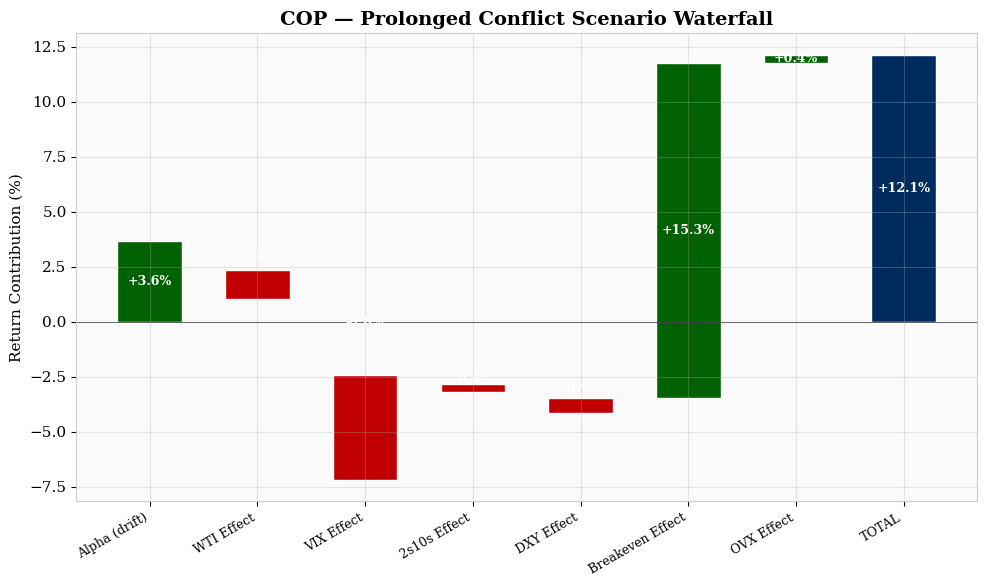

In [5]:
# Waterfall decomposition for COP under Prolonged Conflict
t = 'COP'
if t in reg_results:
    betas = reg_results[t]['betas']
    si = SCENARIO_INPUTS['Prolonged Conflict']
    hd = SCENARIO_HORIZON_DAYS['Prolonged Conflict']
    r_oil = np.log(si['wti_target'] / wti_current)

    contributions = {
        'Alpha (drift)': betas[0] * hd * 100,
        'WTI Effect': betas[1] * r_oil * 100 if len(betas) > 1 else 0,
        'VIX Effect': betas[2] * si['vix_delta'] * 100 if len(betas) > 2 else 0,
        '2s10s Effect': betas[3] * si['spread_2s10s_delta'] * 100 if len(betas) > 3 else 0,
        'DXY Effect': betas[4] * np.log(1 + si.get('dxy_pct', 0)) * 100 if len(betas) > 4 else 0,
        'Breakeven Effect': betas[5] * si.get('breakeven_delta', 0) * 100 if len(betas) > 5 else 0,
        'OVX Effect': betas[6] * si.get('ovx_delta', 0) * 100 if len(betas) > 6 else 0,
    }

    fig, ax = plt.subplots(figsize=(10, 6))
    labels = list(contributions.keys()) + ['TOTAL']
    values = list(contributions.values())
    total = sum(values)
    values.append(total)

    cumulative = [0]
    for v in values[:-1]:
        cumulative.append(cumulative[-1] + v)

    colors = ['#006100' if v > 0 else '#C00000' for v in values[:-1]] + ['#002B5C']
    bottoms = cumulative[:-1] + [0]

    for i, (lbl, val, bot, clr) in enumerate(zip(labels, values, bottoms, colors)):
        if i < len(values) - 1:
            ax.bar(i, val, bottom=bot if val > 0 else bot + val, color=clr,
                   edgecolor='white', width=0.6)
        else:
            ax.bar(i, val, color=clr, edgecolor='white', width=0.6)
        ax.text(i, bot + val/2 if i < len(values)-1 else val/2,
                f'{val:+.1f}%', ha='center', va='center', fontsize=9,
                fontweight='bold', color='white')

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Return Contribution (%)')
    ax.set_title(f'{t} — Prolonged Conflict Scenario Waterfall', fontweight='bold')
    ax.axhline(0, color='#333', linewidth=0.5)
    fig.tight_layout()
    savefig(fig, '30_scenario_waterfall_cop.png')
    plt.show()

## 7.4 Fundamentals Summary Table

  saved 16_fundamentals.png


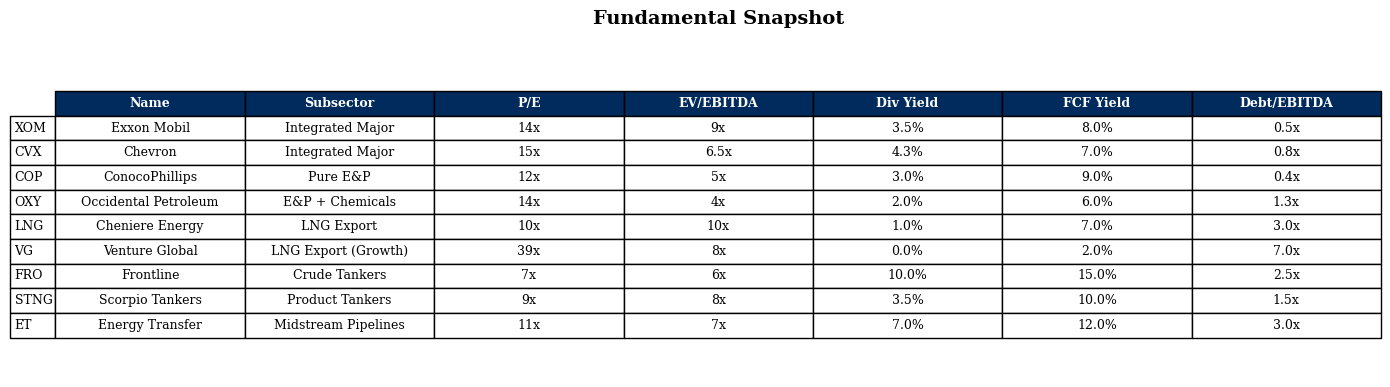

In [6]:
# Fundamental snapshot
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off')

cols = ['Name', 'Subsector', 'P/E', 'EV/EBITDA', 'Div Yield', 'FCF Yield', 'Debt/EBITDA']
rows = []
for t in EQUITY_TICKERS:
    f = FUNDAMENTALS.get(t, {})
    rows.append([
        f.get('name', ''),
        f.get('subsector', ''),
        f'{f.get("pe", "N/A")}x' if f.get('pe') else 'N/A',
        f'{f.get("ev_ebitda", "N/A")}x' if f.get('ev_ebitda') else 'N/A',
        f'{f.get("div_yield", 0)*100:.1f}%' if f.get('div_yield') is not None else 'N/A',
        f'{f.get("fcf_yield", 0)*100:.1f}%' if f.get('fcf_yield') else 'N/A',
        f'{f.get("net_debt_ebitda", "N/A")}x' if f.get('net_debt_ebitda') else 'N/A',
    ])

table = ax.table(cellText=rows, colLabels=cols, rowLabels=EQUITY_TICKERS,
                 cellLoc='center', loc='center')
table.auto_set_font_size(False); table.set_fontsize(9); table.scale(1.2, 1.4)

# Color header
for j in range(len(cols)):
    table[0, j].set_facecolor('#002B5C')
    table[0, j].set_text_props(color='white', fontweight='bold')

ax.set_title('Fundamental Snapshot', fontweight='bold', fontsize=14, pad=20)
fig.tight_layout()
savefig(fig, '16_fundamentals.png')
plt.show()